In [1]:
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
from matplotlib.colors import BoundaryNorm

import dbof.dataset_creation.zarr_dataset_global as zarr_dataset
import dbof.io.filesystems as filesystems

# Load GLOBAL DBOF

## Dataset access config

For convenience the parameters used in accessing the dataset can be stored in config files under ```configs/data_access/```.
These values must match the run configurations.

Example config:
```
data_access:
  s3_endpoint: "https://s3-west.nrp-nautilus.io"
  bucket: "llc"
  folder: "native_grid_dbof_training_data"
  run_id: "year_4x150"
```

If the user prefers, these values can also simply be hardcoded when using the package.

In [2]:
path_to_config = "../../configs/data_access/global.yaml"
with open(path_to_config) as f:
    data_cfg = yaml.safe_load(f)["data_access"]

bucket = data_cfg["bucket"]
folder = data_cfg["folder"]
s3_endpoint = data_cfg["s3_endpoint"]
feature_channels = data_cfg["feature_channels"]
run_id = data_cfg["run_id"]  # update configs/data_access/global.yaml to change this

# User can also simply do
# bucket = "bucket"
# folder = "folder"
# run_id = "my_run_id"

In [3]:
# Build our file system for accessing remote files
fs, fs_synch = filesystems.create_s3_filesystems(s3_endpoint)

# Load the data 

In [4]:
# This reader class will allow easy access to the remotely stored data

reader = zarr_dataset.GlobalZarrDatasetReader(
    bucket=bucket,
    folder=folder,
    run_id=run_id,
    dataset_name="dataset_creation.zarr",
    fs=fs
)

### Plot global maps

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import cmocean.cm as cmo

# ── Choose one channel ─────────────────────────────────────────────────────────
target = "log_gradb"

# Find its index without materializing everything
channels = reader.channel_names
try:
    i = channels.index(target)
except ValueError:
    raise ValueError(f"Channel '{target}' not found. Available: {channels}")

# ── Load just one snapshot, then slice out one channel ─────────────────────────
snapshot = reader.get_snapshot(0)          # shape (C, H, W) (likely lazy-backed)
arr = snapshot[i]                          # shape (H, W)
ds = 8
arr_plot = arr[::ds, ::ds]

# Optional: force compute only this one channel if arr is dask-backed
# arr = np.asarray(arr)

# ── Plot ───────────────────────────────────────────────────────────────────────
cmap = cmo.tempo
label = r'log$|\nabla b|^2$'  # adjust if you want different text

# quick approximate percentiles by subsampling
stride = 20
sample = arr_plot[::stride, ::stride]
finite = np.isfinite(sample)
vmin, vmax = np.nanpercentile(sample[finite], [1, 99])

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
im = ax.imshow(
    arr_plot,
    cmap=cmap,
    vmin=vmin, vmax=vmax,
    origin="upper",
    aspect="auto",
    interpolation="nearest",
)
ax.set_title(label, fontsize=12)
ax.axis("off")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.9)

plt.suptitle(
    f'Global LLC4320 — iteration {reader.time[0]}  |  shape {arr.shape}',
    fontsize=14, y=1.01
)
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [8]:
import cmocean.cm as cmo
from matplotlib.patches import Rectangle

# ── Load the first snapshot ────────────────────────────────────────────────────
snapshot = reader.get_snapshot(0)          # (C, H, W)
channels = reader.channel_names
data_dict = {ch: snapshot[i] for i, ch in enumerate(channels)}

# ── Colormap / label config ────────────────────────────────────────────────────
CMAP_CFG = {
    'Eta':                ('gray',    r'$\eta$ (m)'),
    'Salt':               ('haline',  'Salinity (psu)'),
    'Theta':              ('thermal', 'Temperature (°C)'),
    'U':                  ('speed',   'U velocity (m s⁻¹)'),
    'V':                  ('speed',   'V velocity (m s⁻¹)'),
    'W':                  ('speed',   'W velocity (m s⁻¹)'),
    'relative_vorticity': ('diff',    'Rel. vorticity (s⁻¹)'),
    'log_gradb':          ('tempo',   r'log$|\nabla b|$'),
}
channel_order = ['Eta', 'Salt', 'Theta', 'U', 'V', 'W', 'relative_vorticity', 'log_gradb']

# ── Plot ───────────────────────────────────────────────────────────────────────
ncols = 4
nrows = int(np.ceil(len(channel_order) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows * 5))
axes = axes.flatten()

for ax, ch in zip(axes, channel_order):
    arr = data_dict[ch]
    cmap_name, label = CMAP_CFG[ch]
    cmap = getattr(cmo, cmap_name)
    vmin, vmax = np.nanpercentile(arr[np.isfinite(arr)], [1, 99])
    im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax, origin='upper', aspect='auto',
                   interpolation='nearest')
    ax.set_title(label, fontsize=12)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.9)

for ax in axes[len(channel_order):]:
    ax.set_visible(False)

plt.suptitle(
    f'Global LLC4320 — iteration {reader.time[0]}  |  shape {snapshot.shape[1:]}',
    fontsize=14, y=1.01
)
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

### Plot log_gradb in a specified location.

#### About lat/lon coordinates

The Zarr store uses integer **pixel indices** `(y, x)` — there are no geographic coordinates baked in.  
To select a region by actual **(lat, lon)** you need the `XC`/`YC` grid arrays, which are 2D fields  
(shape 12960 × 17280) giving the geographic coordinate of every pixel.

**Generate them once** with:
```bash
generate-global-grid --output /path/to/llc4320_grid.nc
```
Set `GRID_NC_PATH` below to that path and `USE_LATLON = True`.  
Until then, set `USE_LATLON = False` and specify the region in pixel coordinates.

In [6]:
# ════════════════════════════════════════════════════════════════════════════════
# USER SETTINGS — edit these to choose your region
# ════════════════════════════════════════════════════════════════════════════════

USE_LATLON = False          # ← set True once you have run generate-global-grid-zarr

# ── Option A: pixel coordinates (always available) ────────────────────────────
# (0,0) is top-left of the rectangular image.
# Full image is 12960 rows (y) × 17280 cols (x).
Y_CENTER_PIX  = 4500        # row index of region centre
X_CENTER_PIX  = 5500        # col index of region centre
HALF_H_PIX    = 600         # half-height in pixels
HALF_W_PIX    = 900         # half-width  in pixels

# ── Option B: lat/lon coordinates (requires running generate-global-grid-zarr) ─
LAT_CENTER    =  36.0       # degrees north
LON_CENTER    = -72.0       # degrees east  (use negative for west)
GRID_DATASET  = "llc4320_grid.zarr"   # must match --dataset-name used when writing
HALF_H_KM     = 1000        # approximate half-height in km
HALF_W_KM     = 2000        # approximate half-width  in km

# ════════════════════════════════════════════════════════════════════════════════

H, W = reader.rectangular_shape   # (12960, 17280)

if USE_LATLON:
    import dbof.dataset_creation.zarr_grid_global as zarr_grid

    grid_reader = zarr_grid.GlobalGridZarrReader(
        bucket=bucket,
        folder=folder,
        dataset_name=GRID_DATASET,
        fs=fs,
    )
    XC = grid_reader.lon   # (H, W) — longitude of each pixel
    YC = grid_reader.lat   # (H, W) — latitude  of each pixel
    print(grid_reader)

    # Normalise input longitude to match XC convention (may be 0–360 or −180–180)
    lon_q = LON_CENTER % 360 if XC.max() > 180 else LON_CENTER

    # Find the pixel whose (lat, lon) is closest to the requested centre
    dist = np.sqrt((XC - lon_q) ** 2 + (YC - LAT_CENTER) ** 2)
    cy, cx = np.unravel_index(np.nanargmin(dist), dist.shape)
    print(f"Nearest pixel to ({LAT_CENTER}°N, {LON_CENTER}°E): y={cy}, x={cx}")

    # LLC4320 native resolution ≈ 1/48° ≈ 2.3 km at mid-latitudes
    KM_PER_PIX  = 2.3
    HALF_H_PIX  = int(HALF_H_KM / KM_PER_PIX)
    HALF_W_PIX  = int(HALF_W_KM / KM_PER_PIX)
    Y_CENTER_PIX, X_CENTER_PIX = cy, cx

# Clamp bounding box to image extent
y0 = max(0, Y_CENTER_PIX - HALF_H_PIX)
y1 = min(H, Y_CENTER_PIX + HALF_H_PIX)
x0 = max(0, X_CENTER_PIX - HALF_W_PIX)
x1 = min(W, X_CENTER_PIX + HALF_W_PIX)

print(f"Selected region: rows [{y0}:{y1}], cols [{x0}:{x1}]  →  {y1-y0} × {x1-x0} pixels")

Selected region: rows [3900:5100], cols [4600:6400]  →  1200 × 1800 pixels


NameError: name 'data_dict' is not defined

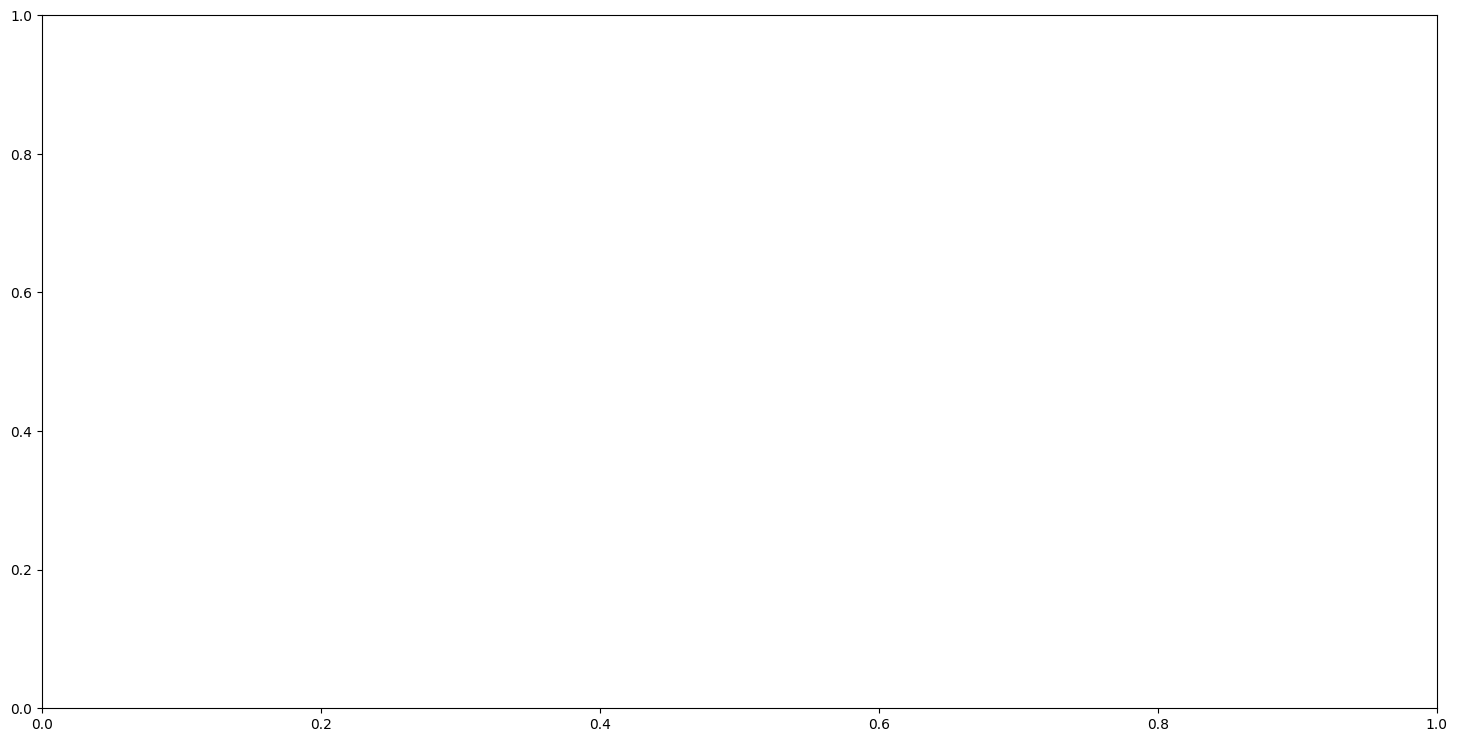

In [7]:
# ── Global map with region box overlaid (Theta as background) ─────────────────
fig, ax = plt.subplots(figsize=(18, 9))

theta = data_dict['Theta']
vmin_t, vmax_t = np.nanpercentile(theta[np.isfinite(theta)], [2, 98])
im = ax.imshow(theta, cmap=cmo.thermal, vmin=vmin_t, vmax=vmax_t,
               origin='upper', aspect='auto', interpolation='nearest')
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02, label='Temperature (°C)')

rect = Rectangle((x0, y0), x1 - x0, y1 - y0,
                 linewidth=2.5, edgecolor='red', facecolor='none', zorder=5)
ax.add_patch(rect)
ax.plot(X_CENTER_PIX, Y_CENTER_PIX, 'r+', markersize=12, markeredgewidth=2, zorder=6)

ax.set_title(
    f'Global Theta — selected region (red box): rows [{y0}:{y1}], cols [{x0}:{x1}]',
    fontsize=12
)
ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# ── Regional subplots ──────────────────────────────────────────────────────────
ncols = 4
nrows = int(np.ceil(len(channel_order) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows * 5))
axes = axes.flatten()

for ax, ch in zip(axes, channel_order):
    arr = data_dict[ch][y0:y1, x0:x1]
    cmap_name, label = CMAP_CFG[ch]
    cmap = getattr(cmo, cmap_name)
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        ax.set_visible(False)
        continue
    vmin, vmax = np.nanpercentile(finite, [1, 99])
    im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax,
                   origin='upper', aspect='auto', interpolation='nearest')
    ax.set_title(label, fontsize=12)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.9)

for ax in axes[len(channel_order):]:
    ax.set_visible(False)

region_label = (
    f'lat={LAT_CENTER}°N, lon={LON_CENTER}°E' if USE_LATLON
    else f'pixel centre y={Y_CENTER_PIX}, x={X_CENTER_PIX}'
)
plt.suptitle(
    f'Regional view — {region_label}  |  {y1-y0} × {x1-x0} px',
    fontsize=14, y=1.01
)
plt.tight_layout()
plt.show()